In [36]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from utils import filt_decompose

In [37]:
plt.rcParams['font.size']=14
plt.rcParams['axes.labelsize']='large'
plt.rcParams['pcolor.shading']='auto'

In [38]:
mooring = 'W310'
ncfile=f'~/data/ProjectsActive/SWOT_NAust/DATA/mooring_sealevel_{mooring}_v3.nc'
ds1 = xr.open_dataset(ncfile)
mooring = 'S245'
ncfile=f'~/data/ProjectsActive/SWOT_NAust/DATA/mooring_sealevel_{mooring}_v3.nc'
ds2 = xr.open_dataset(ncfile)

# ypr = ds['BPR_Pressure']-ds['BPR_Pressure'].mean()
# yf = filt_decompose(ypr, dtsec)

In [39]:
time = ds1.time.values
dt = (time[1:]-time[:-1]).mean()
dtsec = dt.astype(float)*1e-9
dtsec, 1/dtsec
dtsec = 60.

In [40]:
filt_decompose?

Signature:
filt_decompose(
    xraw,
    dt,
    b1=122400,
    b2=14400,
    order=8,
    ftype='sos',
    axis=-1,
)
Docstring: <no docstring>
File:      /data/jupyter-ubuntu/ProjectsActive/SWOT_NAust/NOTEBOOKS/utils.py
Type:      function

In [41]:
eta1 = ds1['eta_b']-ds1['eta_tide_fes'][0,:]
eta2 = ds2['eta_b']-ds2['eta_tide_fes'][0,:]

yf1 = filt_decompose(eta1, dtsec, b1=30*3600, b2=3*3600, order=8)
yf2 = filt_decompose(eta2, dtsec, b1=30*3600, b2=3*3600, order=8)

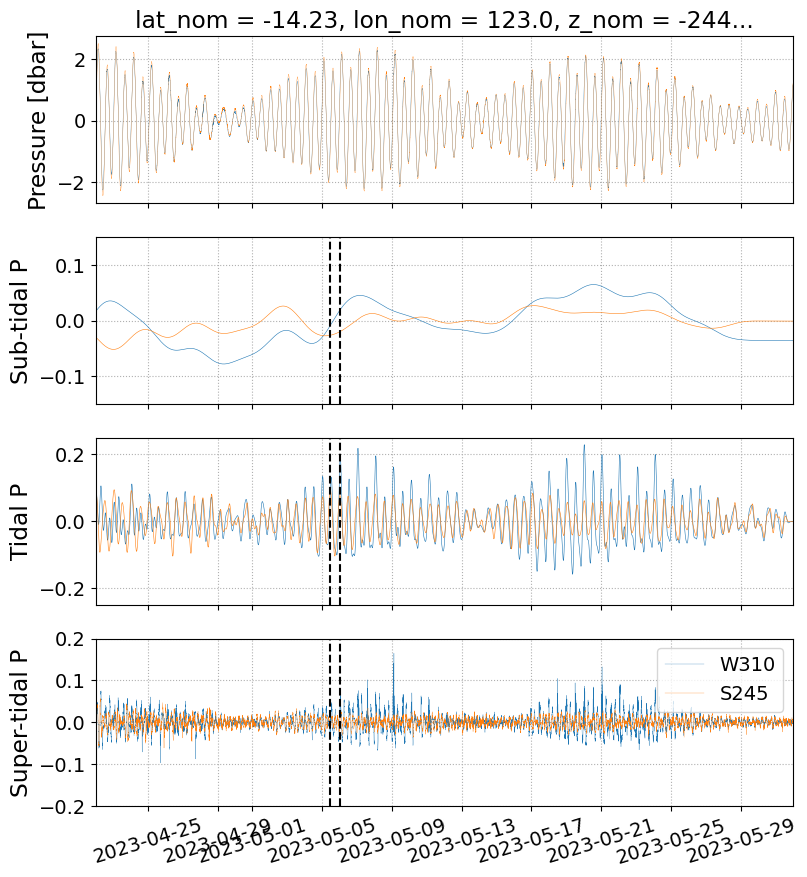

In [42]:
plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
ds1['eta'].plot(lw=0.2)
ds2['eta'].plot(lw=0.2)

ax0.set_xticklabels([])
ax0.set_xlim(time[0],time[-1])
ax0.set_ylabel('Pressure [dbar]')
ax0.set_xlabel('')
plt.grid(True, ls=':')

ax1 = plt.subplot(412)
plt.plot(time, yf1[:,0], lw=0.4)
plt.plot(time, yf2[:,0], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)
ax1.set_xlim(time[0],time[-1])
ax1.set_ylabel('Sub-tidal P')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yf1[:,1], lw=0.4)
plt.plot(time, yf2[:,1], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.25, 0.25)

ax2.set_xlim(time[0],time[-1])
ax2.set_ylabel('Tidal P')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yf1[:,2], lw=0.2, label='W310')
plt.plot(time, yf2[:,2], lw=0.2, label='S245')
plt.legend()

# ax3.set_xticklabels([])
ax3.set_ylim(-0.2, 0.2)
plt.xticks(rotation=17)
ax3.set_xlim(time[0],time[-1])
ax3.set_ylabel('Super-tidal P')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

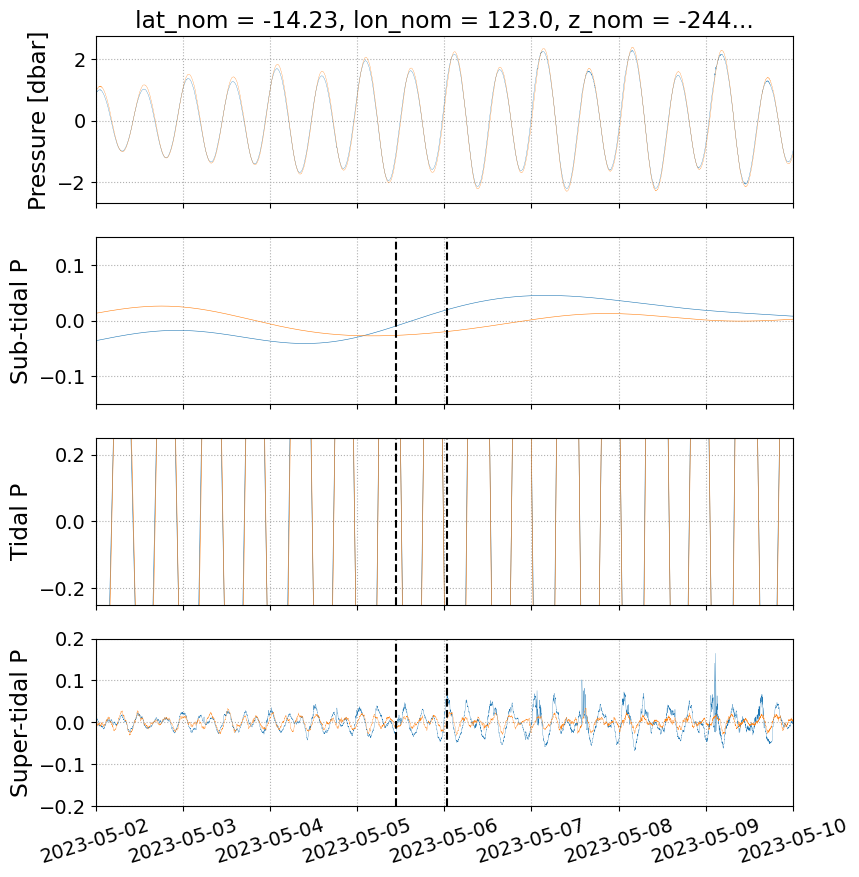

In [43]:
tlim = [np.datetime64('2023-05-02 00:00:00'),
       np.datetime64('2023-05-10 00:00:00')]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
ds1['eta'].plot(lw=0.2)
ds2['eta'].plot(lw=0.2)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('Pressure [dbar]')
ax0.set_xlabel('')
plt.grid(True, ls=':')

ax1 = plt.subplot(412)
plt.plot(time, yf1[:,0], lw=0.4)
plt.plot(time, yf2[:,0], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)
ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('Sub-tidal P')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yf1[:,1]-ds1['eta_tide_fes'][0,:], lw=0.4)
plt.plot(time, yf2[:,1]-ds2['eta_tide_fes'][0,:], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.25, 0.25)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Tidal P')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yf1[:,2], lw=0.2)
plt.plot(time, yf2[:,2], lw=0.2)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.2, 0.2)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal P')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

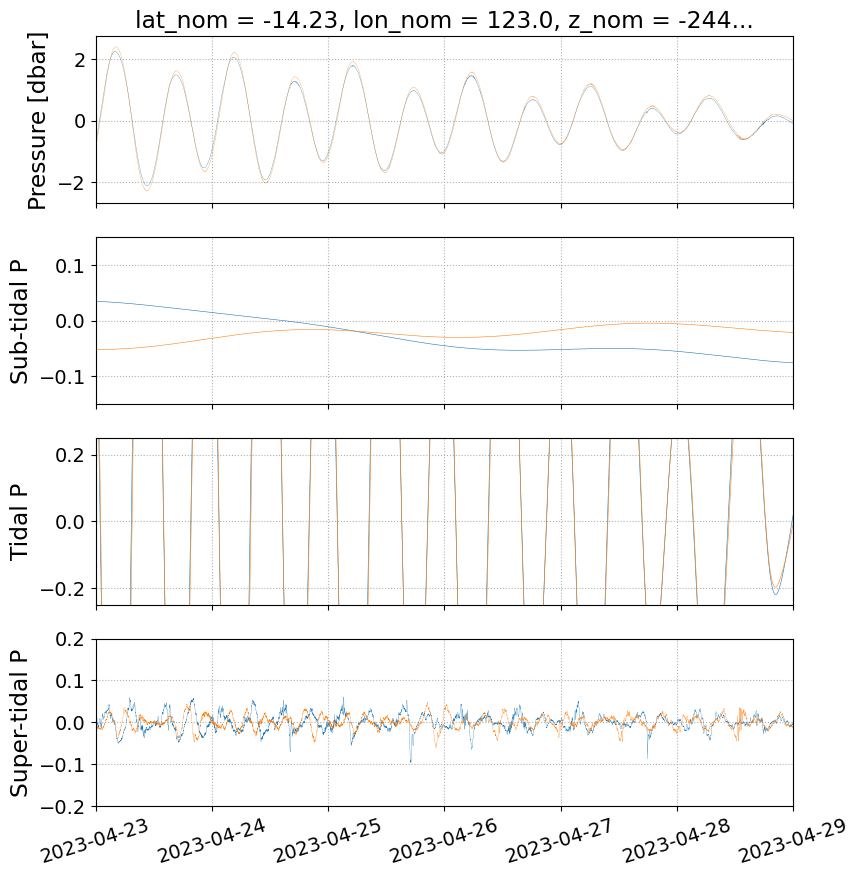

In [44]:
tlim = [np.datetime64('2023-04-23 00:00:00'),
       np.datetime64('2023-04-29 00:00:00')]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
ds1['eta'].plot(lw=0.2)
ds2['eta'].plot(lw=0.2)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('Pressure [dbar]')
ax0.set_xlabel('')
plt.grid(True, ls=':')

ax1 = plt.subplot(412)
plt.plot(time, yf1[:,0], lw=0.4)
plt.plot(time, yf2[:,0], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)
ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('Sub-tidal P')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yf1[:,1]-ds1['eta_tide_fes'][0,:], lw=0.4)
plt.plot(time, yf2[:,1]-ds2['eta_tide_fes'][0,:], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.25, 0.25)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Tidal P')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yf1[:,2], lw=0.2)
plt.plot(time, yf2[:,2], lw=0.2)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.2, 0.2)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal P')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

## Calculate the coherence between the steric and bottom pressure

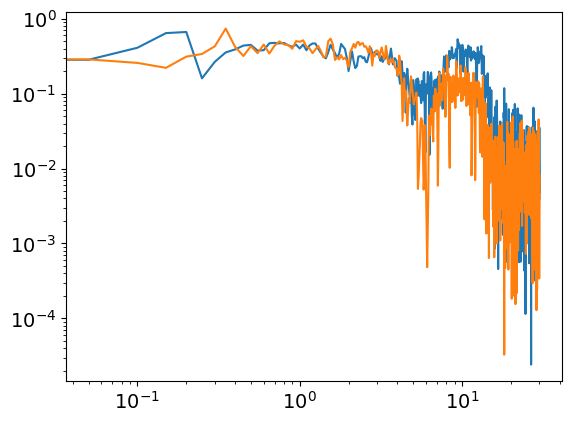

In [45]:
from scipy.signal import coherence
#coherence(x, y, fs=1.0, window='hann', nperseg=None, noverlap=None, nfft=None, detrend='constant', axis=-1)


nperseg = 20*3600/60 # 15 day chunks
f, C_xy_1 = coherence(eta1, ds1['eta_steric'], fs=60./86400, window='hann', nperseg=nperseg, 
                   noverlap=nperseg//2, nfft=None, detrend='constant', axis=-1)

f, C_xy_2 = coherence(eta2, ds2['eta_steric'], fs=60/86400, window='hann', nperseg=nperseg, 
                   noverlap=nperseg//2, nfft=None, detrend='constant', axis=-1)

fig, ax = plt.subplots()
ax.loglog(f*86400, C_xy_1)
ax.loglog(f*86400, C_xy_2)

## Steric height analysis

In [46]:
yfs1 = filt_decompose(ds1['eta_steric'], dtsec, b1=30*3600, b2=3*3600, order=3)
yfs2 = filt_decompose(ds2['eta_steric'], dtsec, b1=30*3600, b2=3*3600, order=3)


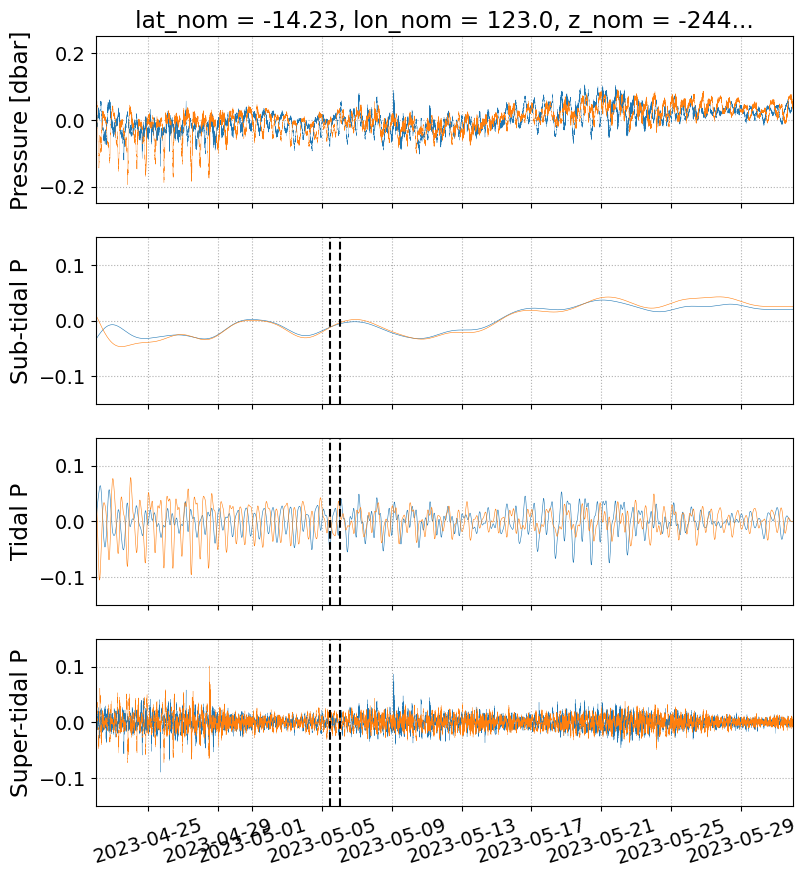

In [47]:
# tlim = [np.datetime64('2023-04-23 00:00:00'),
#        np.datetime64('2023-04-29 00:00:00')]

# tlim = [np.datetime64('2023-05-02 00:00:00'),
#        np.datetime64('2023-05-10 00:00:00')]

tlim = [time[0], time[-1]]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
ds1['eta_steric'].plot(lw=0.2)
ds2['eta_steric'].plot(lw=0.2)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('Pressure [dbar]')
ax0.set_xlabel('')
plt.grid(True, ls=':')
ax0.set_ylim(-0.25, 0.25)


ax1 = plt.subplot(412)
plt.plot(time, yfs1[:,0], lw=0.4)
plt.plot(time, yfs2[:,0], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)

ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('Sub-tidal P')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yfs1[:,1], lw=0.4)
plt.plot(time, yfs2[:,1], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.15, 0.15)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Tidal P')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yfs1[:,2], lw=0.2)
plt.plot(time, yfs2[:,2], lw=0.2)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.15, 0.15)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal P')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

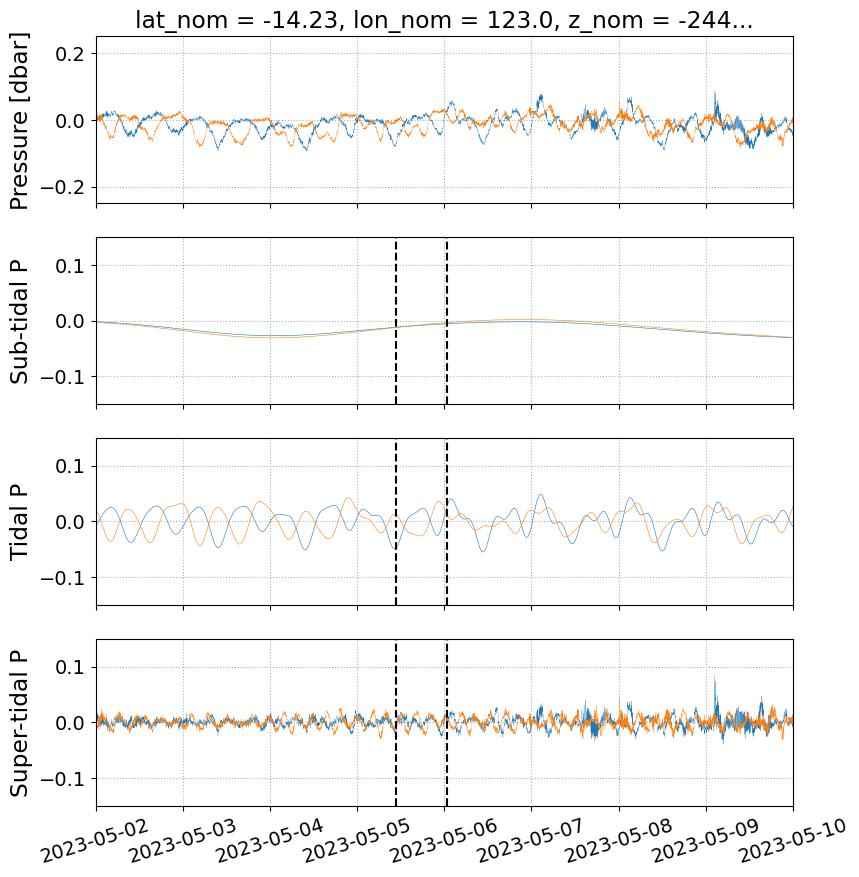

In [48]:
# tlim = [np.datetime64('2023-04-23 00:00:00'),
#        np.datetime64('2023-04-29 00:00:00')]

tlim = [np.datetime64('2023-05-02 00:00:00'),
       np.datetime64('2023-05-10 00:00:00')]

# tlim = [time[0], time[-1]]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
ds1['eta_steric'].plot(lw=0.2)
ds2['eta_steric'].plot(lw=0.2)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('Pressure [dbar]')
ax0.set_xlabel('')
plt.grid(True, ls=':')
ax0.set_ylim(-0.25, 0.25)


ax1 = plt.subplot(412)
plt.plot(time, yfs1[:,0], lw=0.4)
plt.plot(time, yfs2[:,0], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)

ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('Sub-tidal P')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yfs1[:,1], lw=0.4)
plt.plot(time, yfs2[:,1], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.15, 0.15)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Tidal P')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yfs1[:,2], lw=0.2)
plt.plot(time, yfs2[:,2], lw=0.2)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.15, 0.15)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal P')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

# Compare steric and total

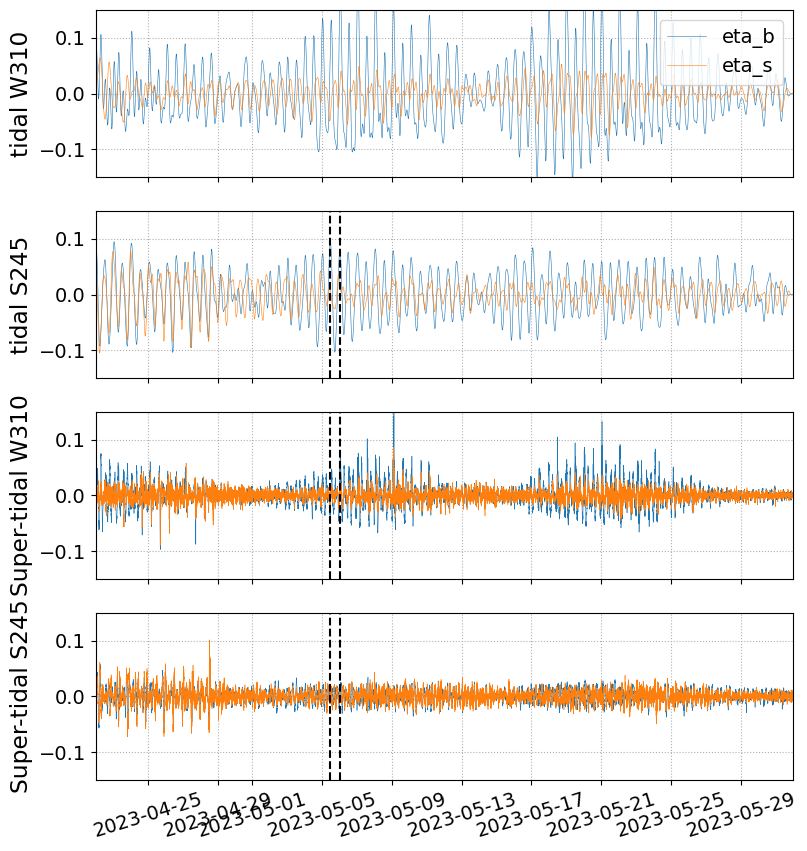

In [49]:
# tlim = [np.datetime64('2023-04-23 00:00:00'),
#        np.datetime64('2023-04-29 00:00:00')]

# tlim = [np.datetime64('2023-05-02 00:00:00'),
#        np.datetime64('2023-05-10 00:00:00')]

tlim = [time[0], time[-1]]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
plt.plot(time, yf1[:,1], lw=0.4, label='eta_b')
plt.plot(time, yfs1[:,1], lw=0.4, label='eta_s')

# plt.plot(time, yfs2[:,0], lw=0.4)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('tidal W310')
ax0.set_xlabel('')
plt.grid(True, ls=':')
ax0.set_ylim(-0.15, 0.15)
plt.legend()

ax1 = plt.subplot(412)
plt.plot(time, yf2[:,1], lw=0.4)
plt.plot(time, yfs2[:,1], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)

ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('tidal S245')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yf1[:,2], lw=0.4)
plt.plot(time, yfs1[:,2], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.15, 0.15)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Super-tidal W310')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yf2[:,2], lw=0.4)
plt.plot(time, yfs2[:,2], lw=0.4)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.15, 0.15)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal S245')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

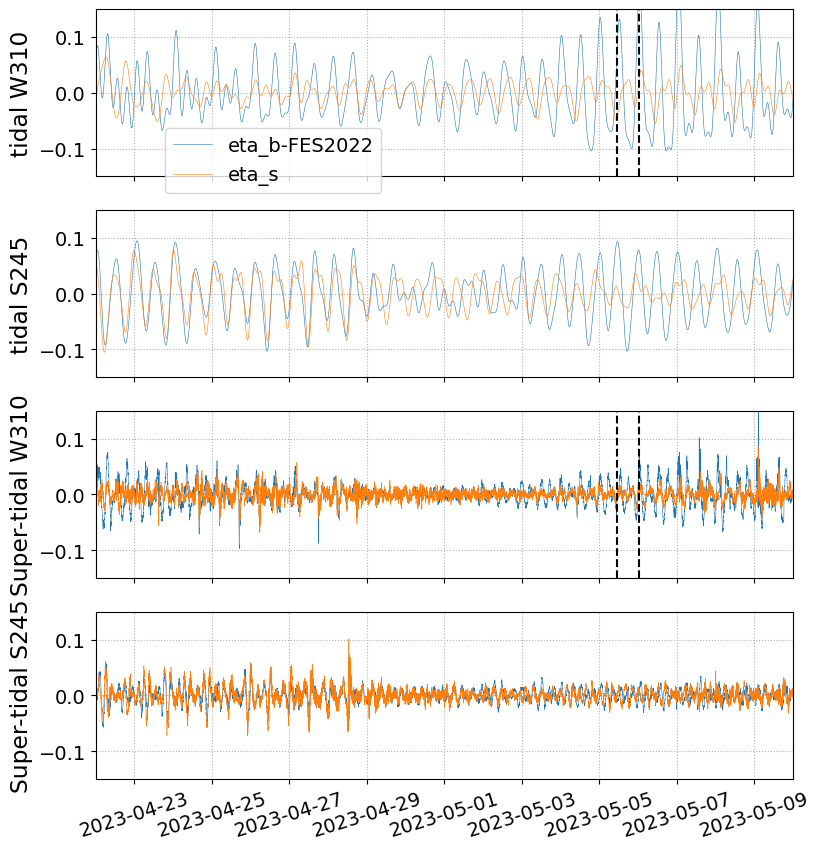

In [59]:
tlim = [np.datetime64('2023-04-22 00:00:00'),
       np.datetime64('2023-05-10 00:00:00')]

# tlim = [np.datetime64('2023-05-02 00:00:00'),
#        np.datetime64('2023-05-10 00:00:00')]

# tlim = [time[0], time[-1]]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
plt.plot(time, yf1[:,1], lw=0.4, label='eta_b-FES2022')
plt.plot(time, yfs1[:,1], lw=0.4, label='eta_s')

# plt.plot(time, yfs2[:,0], lw=0.4)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('tidal W310')
ax0.set_xlabel('')
plt.grid(True, ls=':')
ax0.set_ylim(-0.15, 0.15)
plt.legend(loc=(0.1,-0.1))
ax0.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax0.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax1 = plt.subplot(412)
plt.plot(time, yf2[:,1], lw=0.4)
plt.plot(time, yfs2[:,1], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)

ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('tidal S245')
plt.grid(True, ls=':')
# ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
# ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yf1[:,2], lw=0.4)
plt.plot(time, yfs1[:,2], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.15, 0.15)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Super-tidal W310')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yf2[:,2], lw=0.4)
plt.plot(time, yfs2[:,2], lw=0.4)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.15, 0.15)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal S245')
plt.grid(True, ls=':')

plt.savefig('../FIGURES/steric_bottompressure_W310S245_0423_0509.png')

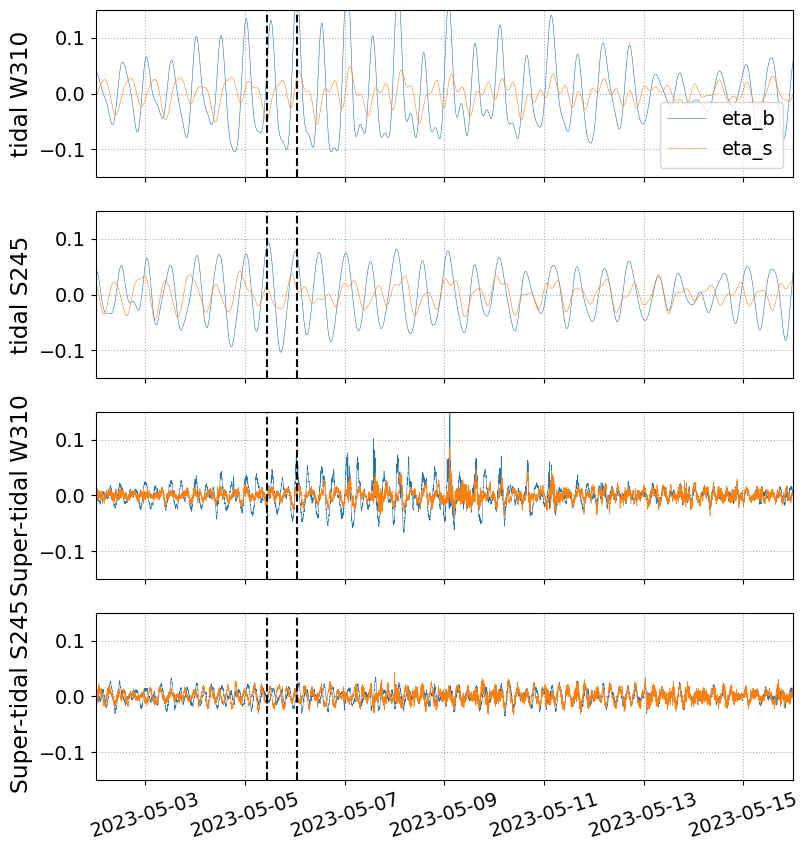

In [51]:
# tlim = [np.datetime64('2023-04-23 00:00:00'),
#        np.datetime64('2023-04-29 00:00:00')]

tlim = [np.datetime64('2023-05-02 00:00:00'),
       np.datetime64('2023-05-16 00:00:00')]

# tlim = [time[0], time[-1]]

plt.figure(figsize=(9,10))

ax0 = plt.subplot(411)
plt.plot(time, yf1[:,1], lw=0.4, label='eta_b')
plt.plot(time, yfs1[:,1], lw=0.4, label='eta_s')

# plt.plot(time, yfs2[:,0], lw=0.4)

ax0.set_xticklabels([])
ax0.set_xlim(tlim[0],tlim[-1])
ax0.set_ylabel('tidal W310')
ax0.set_xlabel('')
plt.grid(True, ls=':')
ax0.set_ylim(-0.15, 0.15)
plt.legend()
ax0.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax0.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax1 = plt.subplot(412)
plt.plot(time, yf2[:,1], lw=0.4)
plt.plot(time, yfs2[:,1], lw=0.4)

ax1.set_xticklabels([])
ax1.set_ylim(-0.15, 0.15)

ax1.set_xlim(tlim[0],tlim[-1])
ax1.set_ylabel('tidal S245')
plt.grid(True, ls=':')
ax1.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax1.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')

ax2 = plt.subplot(413)
plt.plot(time, yf1[:,2], lw=0.4)
plt.plot(time, yfs1[:,2], lw=0.4)

ax2.set_xticklabels([])
# ax2.set_ylim(-2.5, 2.5)
ax2.set_ylim(-0.15, 0.15)

ax2.set_xlim(tlim[0],tlim[-1])
ax2.set_ylabel('Super-tidal W310')
plt.grid(True, ls=':')

ax2.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax2.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')
ax3 = plt.subplot(414)
plt.plot(time, yf2[:,2], lw=0.4)
plt.plot(time, yfs2[:,2], lw=0.4)

# ax3.set_xticklabels([])
ax3.set_ylim(-0.15, 0.15)
plt.xticks(rotation=17)
ax3.set_xlim(tlim[0],tlim[-1])

ax3.set_ylabel('Super-tidal S245')
plt.grid(True, ls=':')
ax3.axvline(np.datetime64('2023-05-05 10:49:07'),color='black',linestyle='--')
ax3.axvline(np.datetime64('2023-05-06 00:51:09'),color='black',linestyle='--')